STEP 3

In [1]:
# ── CELL 1: Install and Import ──────────────────────────────
!pip install mrmr-selection -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
from mrmr import mrmr_classif

print("✅ All imports done!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 2.8 MB/s eta 0:00:00
✅ All imports done!


In [2]:
# ── CELL 2: Load the feature CSV ────────────────────────────
# Upload your features.csv to Colab first, then run this cell

df = pd.read_csv('features.csv')

print(f"Dataset shape : {df.shape}")
print(f"Total recordings : {len(df)}")
print(f"Total features : {df.shape[1] - 3}")  # minus Filename, Class, Label
print(f"\nClass distribution:")
print(df['Class'].value_counts())

Dataset shape : (1800, 417)
Total recordings : 1800
Total features : 414

Class distribution:
Class
Bearing      225
Flywheel     225
Healthy      225
LIV          225
LOV          225
NRV          225
Piston       225
Riderbelt    225
Name: count, dtype: int64


In [3]:
# ── CELL 3: Separate X (features) and y (labels) ────────────

# Drop non-feature columns
X = df.drop(columns=['Filename', 'Class', 'Label'])
y = df['Label']   # numeric: 0=Bearing, 1=Flywheel, ... 7=Riderbelt

# Class name mapping (for readable output later)
class_names = {0:'Bearing', 1:'Flywheel', 2:'Healthy',
               3:'LIV', 4:'LOV', 5:'NRV', 6:'Piston', 7:'Riderbelt'}

feature_names = list(X.columns)

print(f"X shape : {X.shape}   → (recordings × features)")
print(f"y shape : {y.shape}")
print(f"\nFeature breakdown:")
for prefix in ['FFT', 'DCT', 'STFT', 'WVD', 'WPT']:
    count = len([c for c in feature_names if c.startswith(prefix)])
    print(f"  {prefix:5s}: {count:3d} features")
print(f"  {'TOTAL':5s}: {len(feature_names):3d} features")

X shape : (1800, 414)   → (recordings × features)
y shape : (1800,)

Feature breakdown:
  FFT  :   8 features
  DCT  :   8 features
  STFT :  72 features
  WVD  :  72 features
  WPT  : 254 features
  TOTAL: 414 features


In [4]:
# ── CELL 4: mRMR Feature Selection ──────────────────────────
# Paper: Section VI, Step 3
# Select top 25 features from 414 using mRMR

N_FEATURES = 25   # as specified in the paper

print(f"Running mRMR on {X.shape[1]} features to select top {N_FEATURES}...")
print("(This may take 1-2 minutes)\n")

selected_feature_names = mrmr_classif(
    X=X,
    y=y,
    K=N_FEATURES,
    show_progress=True
)

print(f"\n✅ mRMR complete!")
print(f"\nTop {N_FEATURES} selected features (ranked by importance):")
print("-" * 45)
for rank, feat in enumerate(selected_feature_names):
    # Find which transform this feature belongs to
    transform = feat.split('_')[0]
    print(f"  Rank {rank+1:2d}: {feat:15s}  [{transform}]")

Running mRMR on 414 features to select top 25...
(This may take 1-2 minutes)



100%|██████████| 25/25 [00:04<00:00,  5.11it/s]


✅ mRMR complete!

Top 25 selected features (ranked by importance):
---------------------------------------------
  Rank  1: DCT_3            [DCT]
  Rank  2: WVD_60           [WVD]
  Rank  3: FFT_3            [FFT]
  Rank  4: STFT_14          [STFT]
  Rank  5: WPT_130          [WPT]
  Rank  6: WPT_228          [WPT]
  Rank  7: WPT_144          [WPT]
  Rank  8: WPT_125          [WPT]
  Rank  9: WPT_64           [WPT]
  Rank 10: WPT_121          [WPT]
  Rank 11: WPT_62           [WPT]
  Rank 12: WPT_69           [WPT]
  Rank 13: WPT_244          [WPT]
  Rank 14: STFT_17          [STFT]
  Rank 15: WPT_252          [WPT]
  Rank 16: WVD_50           [WVD]
  Rank 17: WPT_56           [WPT]
  Rank 18: WPT_212          [WPT]
  Rank 19: STFT_19          [STFT]
  Rank 20: WVD_51           [WVD]
  Rank 21: WPT_113          [WPT]
  Rank 22: WPT_208          [WPT]
  Rank 23: WPT_180          [WPT]
  Rank 24: DCT_4            [DCT]
  Rank 25: WVD_23           [WVD]


In [5]:
# ── CELL 5: Save selected features ──────────────────────────
# Paper says: "store indices in a model file named Feature_Select"

# Get the column indices of selected features
selected_indices = [feature_names.index(f) for f in selected_feature_names]

# Save as pickle file (Feature_Select.pkl)
feature_select_data = {
    'selected_feature_names': selected_feature_names,
    'selected_indices':       selected_indices,
    'n_features':             N_FEATURES
}

with open('Feature_Select.pkl', 'wb') as f:
    pickle.dump(feature_select_data, f)

print("✅ Feature_Select.pkl saved!")
print(f"\nContents:")
print(f"  Selected feature names : {selected_feature_names}")
print(f"  Selected indices       : {selected_indices}")

# Also get the reduced feature matrix for next step (SVM training)
X_selected = X[selected_feature_names].values
print(f"\nReduced feature matrix shape: {X_selected.shape}")
print(f"  (was {X.shape[0]} × {X.shape[1]}, now {X_selected.shape[0]} × {X_selected.shape[1]})")

✅ Feature_Select.pkl saved!

Contents:
  Selected feature names : ['DCT_3', 'WVD_60', 'FFT_3', 'STFT_14', 'WPT_130', 'WPT_228', 'WPT_144', 'WPT_125', 'WPT_64', 'WPT_121', 'WPT_62', 'WPT_69', 'WPT_244', 'STFT_17', 'WPT_252', 'WVD_50', 'WPT_56', 'WPT_212', 'STFT_19', 'WVD_51', 'WPT_113', 'WPT_208', 'WPT_180', 'DCT_4', 'WVD_23']
  Selected indices       : [10, 147, 2, 29, 289, 387, 303, 284, 223, 280, 221, 228, 403, 32, 411, 137, 215, 371, 34, 138, 272, 367, 339, 11, 110]

Reduced feature matrix shape: (1800, 25)
  (was 1800 × 414, now 1800 × 25)


Selected features by transform:
-----------------------------------
  WPT  : 15  ███████████████
  WVD  :  4  ████
  STFT :  3  ███
  DCT  :  2  ██
  FFT  :  1  █


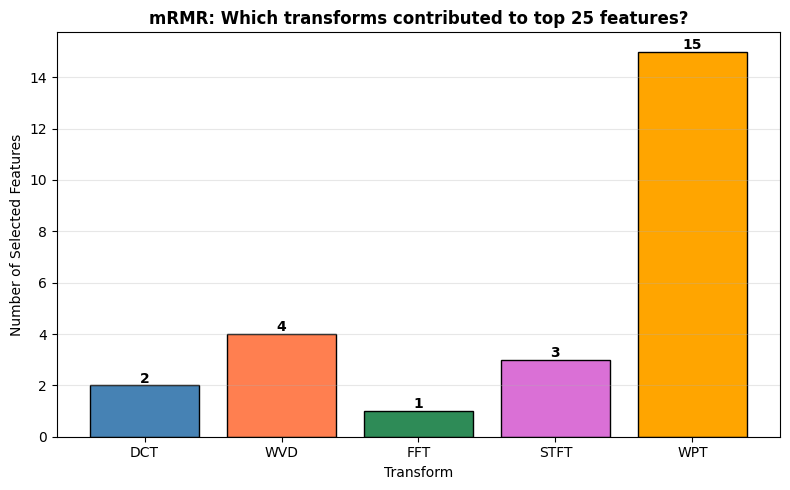

✅ Plot saved as mrmr_transform_breakdown.png


In [6]:
# ── CELL 6: Visualise selected feature breakdown ─────────────

transform_counts = {}
for feat in selected_feature_names:
    t = feat.split('_')[0]
    transform_counts[t] = transform_counts.get(t, 0) + 1

print("Selected features by transform:")
print("-" * 35)
for t, count in sorted(transform_counts.items(), key=lambda x: -x[1]):
    bar = '█' * count
    print(f"  {t:5s}: {count:2d}  {bar}")

# Bar chart
plt.figure(figsize=(8, 5))
bars = plt.bar(transform_counts.keys(), transform_counts.values(),
               color=['steelblue','coral','seagreen','orchid','orange'],
               edgecolor='black')
for b in bars:
    plt.text(b.get_x() + b.get_width()/2, b.get_height() + 0.1,
             str(int(b.get_height())), ha='center', fontweight='bold')
plt.ylabel("Number of Selected Features")
plt.xlabel("Transform")
plt.title(f"mRMR: Which transforms contributed to top {N_FEATURES} features?",
          fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('mrmr_transform_breakdown.png', dpi=150)
plt.show()
print("✅ Plot saved as mrmr_transform_breakdown.png")

In [7]:
# ── CELL 7: Verify Feature_Select.pkl loads correctly ────────
# This is what Step 4 (SVM) will use

with open('Feature_Select.pkl', 'rb') as f:
    loaded = pickle.load(f)

print("✅ Feature_Select.pkl loads correctly!")
print(f"\nLoaded contents:")
print(f"  n_features             : {loaded['n_features']}")
print(f"  selected_indices       : {loaded['selected_indices']}")
print(f"  selected_feature_names : {loaded['selected_feature_names']}")

# Show how Step 4 will use it
print(f"\nHow Step 4 (SVM) will use this file:")
print(f"  X_for_training = X_full[:, selected_indices]")
print(f"  → Shape will be: (1800, {loaded['n_features']})")

✅ Feature_Select.pkl loads correctly!

Loaded contents:
  n_features             : 25
  selected_indices       : [10, 147, 2, 29, 289, 387, 303, 284, 223, 280, 221, 228, 403, 32, 411, 137, 215, 371, 34, 138, 272, 367, 339, 11, 110]
  selected_feature_names : ['DCT_3', 'WVD_60', 'FFT_3', 'STFT_14', 'WPT_130', 'WPT_228', 'WPT_144', 'WPT_125', 'WPT_64', 'WPT_121', 'WPT_62', 'WPT_69', 'WPT_244', 'STFT_17', 'WPT_252', 'WVD_50', 'WPT_56', 'WPT_212', 'STFT_19', 'WVD_51', 'WPT_113', 'WPT_208', 'WPT_180', 'DCT_4', 'WVD_23']

How Step 4 (SVM) will use this file:
  X_for_training = X_full[:, selected_indices]
  → Shape will be: (1800, 25)


STEP 4

In [8]:
# ── CELL 8: Imports for SVM ──────────────────────────────────
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_score, cross_val_predict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, classification_report
import pickle
import numpy as np
import matplotlib.pyplot as plt

print("✅ SVM imports ready!")

✅ SVM imports ready!


In [9]:
# ── CELL 9: Load selected features ───────────────────────────

# Load the Feature_Select file saved in Step 3
with open('Feature_Select.pkl', 'rb') as f:
    feature_select = pickle.load(f)

selected_names   = feature_select['selected_feature_names']
selected_indices = feature_select['selected_indices']

# Get reduced feature matrix using selected 25 features
X_selected = X[selected_names].values   # shape: (1800, 25)
y_labels   = y.values                   # shape: (1800,)

print(f"✅ Feature_Select.pkl loaded!")
print(f"\nX_selected shape : {X_selected.shape}  (1800 recordings × 25 features)")
print(f"y shape          : {y_labels.shape}")
print(f"\nClass distribution:")
for label, name in class_names.items():
    count = np.sum(y_labels == label)
    print(f"  Class {label} ({name:10s}): {count} recordings")

✅ Feature_Select.pkl loaded!

X_selected shape : (1800, 25)  (1800 recordings × 25 features)
y shape          : (1800,)

Class distribution:
  Class 0 (Bearing   ): 225 recordings
  Class 1 (Flywheel  ): 225 recordings
  Class 2 (Healthy   ): 225 recordings
  Class 3 (LIV       ): 225 recordings
  Class 4 (LOV       ): 225 recordings
  Class 5 (NRV       ): 225 recordings
  Class 6 (Piston    ): 225 recordings
  Class 7 (Riderbelt ): 225 recordings


In [10]:
# ── CELL 10: Scale features ───────────────────────────────────
# SVM is sensitive to feature scale, so we standardize
# (mean=0, std=1) before training

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_selected)

# Save scaler too — needed during test phase
with open('Scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print(f"✅ Features scaled!")
print(f"   Mean (should be ~0): {X_scaled.mean():.6f}")
print(f"   Std  (should be ~1): {X_scaled.std():.6f}")
print(f"   Scaler saved as Scaler.pkl")

✅ Features scaled!
   Mean (should be ~0): 0.000000
   Std  (should be ~1): 1.000000
   Scaler saved as Scaler.pkl


In [11]:
# ── CELL 11: Grid Search (C and gamma) ───────────────────────
# Paper: grid search over C and gamma to find best SVM params
# We test log2(C) in {-2,-1,0,...,11,12}
# and log2(gamma) in {-10,-9,...,3,4}
# Here we use a smaller grid for speed — same idea

print("Running Grid Search to find best C and gamma...")
print("Testing C values    : [0.1, 1, 10, 100, 1000]")
print("Testing gamma values: [0.0001, 0.001, 0.01, 0.1, 1]")
print("Cross-validation    : 5-fold")
print("(This may take 3-5 minutes)\n")

param_grid = {
    'C'    : [0.1, 1, 10, 100, 1000],
    'gamma': [0.0001, 0.001, 0.01, 0.1, 1]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    SVC(kernel='rbf', decision_function_shape='ovo'),  # OAO = ovo
    param_grid,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_scaled, y_labels)

best_C     = grid_search.best_params_['C']
best_gamma = grid_search.best_params_['gamma']
best_score = grid_search.best_score_

print(f"\n✅ Grid Search complete!")
print(f"   Best C     : {best_C}")
print(f"   Best gamma : {best_gamma}")
print(f"   Best CV accuracy : {best_score*100:.2f}%")

Running Grid Search to find best C and gamma...
Testing C values    : [0.1, 1, 10, 100, 1000]
Testing gamma values: [0.0001, 0.001, 0.01, 0.1, 1]
Cross-validation    : 5-fold
(This may take 3-5 minutes)

Fitting 5 folds for each of 25 candidates, totalling 125 fits

✅ Grid Search complete!
   Best C     : 1000
   Best gamma : 0.01
   Best CV accuracy : 99.56%


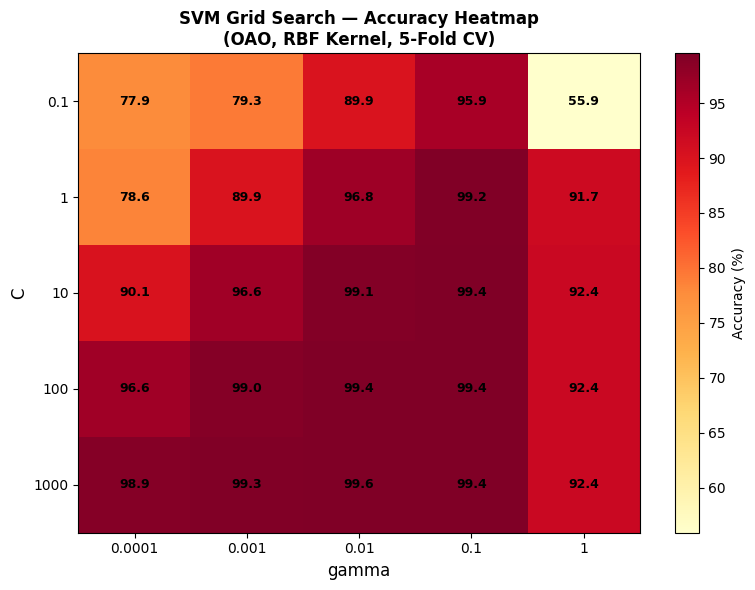

✅ Heatmap saved as grid_search_heatmap.png


In [12]:
# ── CELL 12: Grid Search Heatmap ─────────────────────────────

scores = grid_search.cv_results_['mean_test_score'].reshape(5, 5)

plt.figure(figsize=(8, 6))
plt.imshow(scores * 100, cmap='YlOrRd', aspect='auto')
plt.colorbar(label='Accuracy (%)')
plt.xticks(range(5), [str(g) for g in param_grid['gamma']])
plt.yticks(range(5), [str(c) for c in param_grid['C']])
plt.xlabel("gamma", fontsize=12)
plt.ylabel("C", fontsize=12)
plt.title("SVM Grid Search — Accuracy Heatmap\n(OAO, RBF Kernel, 5-Fold CV)",
          fontweight='bold')

for i in range(5):
    for j in range(5):
        plt.text(j, i, f"{scores[i,j]*100:.1f}",
                 ha='center', va='center', fontsize=9, fontweight='bold',
                 color='black' if scores[i,j] > 0.5 else 'white')

plt.tight_layout()
plt.savefig('grid_search_heatmap.png', dpi=150)
plt.show()
print("✅ Heatmap saved as grid_search_heatmap.png")

In [13]:
# ── CELL 13: Train Final SVM ──────────────────────────────────
# Paper: OAO multiclass SVM with RBF kernel
# decision_function_shape='ovo' = One Against One (OAO)

print(f"Training final SVM with best params: C={best_C}, gamma={best_gamma}")

final_svm = SVC(
    kernel='rbf',
    C=best_C,
    gamma=best_gamma,
    decision_function_shape='ovo',   # OAO as in paper
    random_state=42
)

final_svm.fit(X_scaled, y_labels)

# Save the trained model
with open('SVM_Model.pkl', 'wb') as f:
    pickle.dump(final_svm, f)

print(f"✅ SVM model trained and saved as SVM_Model.pkl!")
print(f"\nModel details:")
print(f"  Kernel              : RBF")
print(f"  Multiclass strategy : OAO (One Against One)")
print(f"  C                   : {best_C}")
print(f"  gamma               : {best_gamma}")
print(f"  Number of classes   : {len(np.unique(y_labels))}")
print(f"  Training samples    : {X_scaled.shape[0]}")
print(f"  Features used       : {X_scaled.shape[1]}")

Training final SVM with best params: C=1000, gamma=0.01
✅ SVM model trained and saved as SVM_Model.pkl!

Model details:
  Kernel              : RBF
  Multiclass strategy : OAO (One Against One)
  C                   : 1000
  gamma               : 0.01
  Number of classes   : 8
  Training samples    : 1800
  Features used       : 25


In [14]:
# ── CELL 14: Cross Validation across k folds ─────────────────
# Paper tests k = 2, 3, 4, 5, 10 folds — we do the same

print("Cross-validation results across different k values:")
print("(Reproduces Tables III-VII from the paper)")
print("-" * 45)

svm_eval = SVC(kernel='rbf', C=best_C, gamma=best_gamma,
               decision_function_shape='ovo', random_state=42)

k_values = [2, 3, 4, 5, 10]
cv_results = {}

for k in k_values:
    cv_k = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)
    scores = cross_val_score(svm_eval, X_scaled, y_labels,
                             cv=cv_k, scoring='accuracy')
    cv_results[k] = scores
    fold_str = '  '.join([f"{s*100:.1f}%" for s in scores])
    print(f"\n  {k}-Fold:")
    print(f"    Fold accuracies : {fold_str}")
    print(f"    Mean accuracy   : {scores.mean()*100:.2f}%")
    print(f"    Std deviation   : {scores.std()*100:.2f}%")

print("\n✅ Cross-validation complete!")

Cross-validation results across different k values:
(Reproduces Tables III-VII from the paper)
---------------------------------------------

  2-Fold:
    Fold accuracies : 98.7%  99.1%
    Mean accuracy   : 98.89%
    Std deviation   : 0.22%

  3-Fold:
    Fold accuracies : 98.8%  99.3%  100.0%
    Mean accuracy   : 99.39%
    Std deviation   : 0.48%

  4-Fold:
    Fold accuracies : 98.9%  99.8%  99.3%  100.0%
    Mean accuracy   : 99.50%
    Std deviation   : 0.43%

  5-Fold:
    Fold accuracies : 99.4%  99.2%  99.7%  99.4%  100.0%
    Mean accuracy   : 99.56%
    Std deviation   : 0.28%

  10-Fold:
    Fold accuracies : 100.0%  100.0%  98.3%  99.4%  100.0%  98.9%  98.9%  100.0%  100.0%  100.0%
    Mean accuracy   : 99.56%
    Std deviation   : 0.60%

✅ Cross-validation complete!


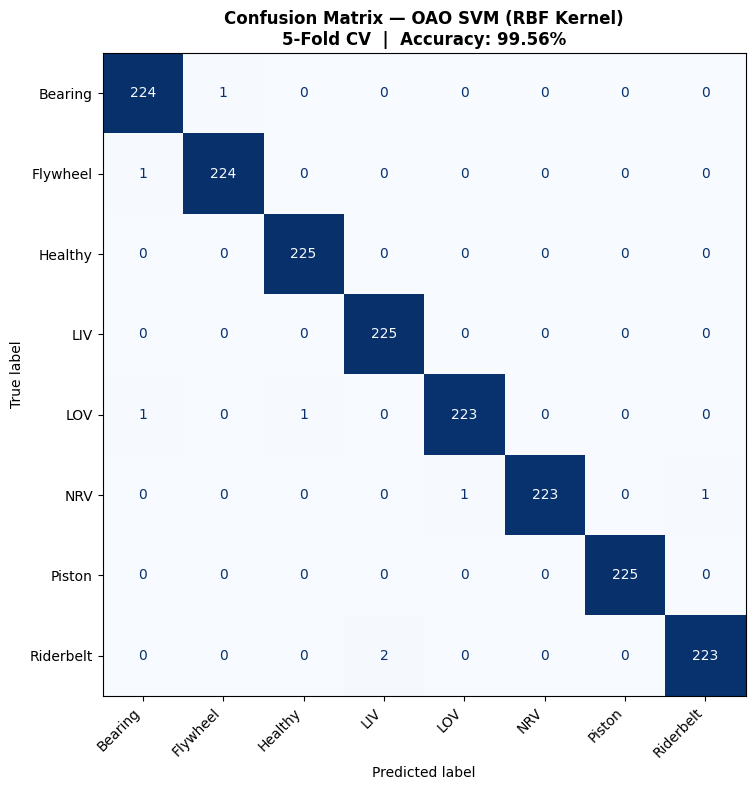


✅ Final Accuracy : 99.56%

Per-class report:
              precision    recall  f1-score   support

     Bearing       0.99      1.00      0.99       225
    Flywheel       1.00      1.00      1.00       225
     Healthy       1.00      1.00      1.00       225
         LIV       0.99      1.00      1.00       225
         LOV       1.00      0.99      0.99       225
         NRV       1.00      0.99      1.00       225
      Piston       1.00      1.00      1.00       225
   Riderbelt       1.00      0.99      0.99       225

    accuracy                           1.00      1800
   macro avg       1.00      1.00      1.00      1800
weighted avg       1.00      1.00      1.00      1800



In [15]:
# ── CELL 15: Confusion Matrix ────────────────────────────────

svm_eval = SVC(kernel='rbf', C=best_C, gamma=best_gamma,
               decision_function_shape='ovo', random_state=42)

cv_5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
y_pred = cross_val_predict(svm_eval, X_scaled, y_labels, cv=cv_5)

final_accuracy = accuracy_score(y_labels, y_pred)

label_names = ['Bearing','Flywheel','Healthy','LIV','LOV','NRV','Piston','Riderbelt']

cm = confusion_matrix(y_labels, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)

fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title(f"Confusion Matrix — OAO SVM (RBF Kernel)\n"
          f"5-Fold CV  |  Accuracy: {final_accuracy*100:.2f}%",
          fontweight='bold', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

print(f"\n✅ Final Accuracy : {final_accuracy*100:.2f}%")
print(f"\nPer-class report:")
print(classification_report(y_labels, y_pred, target_names=label_names))

In [16]:
# ── CELL 16: Project Summary ─────────────────────────────────

print("=" * 55)
print("        STEP 4 COMPLETE — TRAINING SUMMARY")
print("=" * 55)
print(f"""
PAPER  : Verma et al., IEEE Transactions on Reliability, 2016

PIPELINE COMPLETED:
  Step 1 ✅  Pre-processing
  Step 2 ✅  Feature Extraction (FFT, WPT, DCT, STFT, WVD)
  Step 3 ✅  mRMR Feature Selection → 25 features
  Step 4 ✅  OAO SVM with RBF kernel → trained & saved

FEATURE SELECTION (Step 3 results):
  Total features extracted : 414
  Features selected (mRMR) : 25
  Top transform            : WPT (15 features)

SVM MODEL (Step 4 results):
  Kernel                   : RBF
  Multiclass strategy      : OAO (One Against One)
  Best C                   : {best_C}
  Best gamma               : {best_gamma}
  Final Accuracy (5-fold)  : {final_accuracy*100:.2f}%

SAVED FILES:
  Feature_Select.pkl  → 25 selected feature indices
  Scaler.pkl          → StandardScaler (for test phase)
  SVM_Model.pkl       → Trained SVM classifier
""")
print("=" * 55)

        STEP 4 COMPLETE — TRAINING SUMMARY

PAPER  : Verma et al., IEEE Transactions on Reliability, 2016

PIPELINE COMPLETED:
  Step 1 ✅  Pre-processing
  Step 2 ✅  Feature Extraction (FFT, WPT, DCT, STFT, WVD)
  Step 3 ✅  mRMR Feature Selection → 25 features
  Step 4 ✅  OAO SVM with RBF kernel → trained & saved

FEATURE SELECTION (Step 3 results):
  Total features extracted : 414
  Features selected (mRMR) : 25
  Top transform            : WPT (15 features)

SVM MODEL (Step 4 results):
  Kernel                   : RBF
  Multiclass strategy      : OAO (One Against One)
  Best C                   : 1000
  Best gamma               : 0.01
  Final Accuracy (5-fold)  : 99.56%

SAVED FILES:
  Feature_Select.pkl  → 25 selected feature indices
  Scaler.pkl          → StandardScaler (for test phase)
  SVM_Model.pkl       → Trained SVM classifier

